## Preparing API

DataService 점검용 Jupyter Notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.service import fixed_income

DB_PATH = '../database/alternative_data.duckdb'

### MacroService

In [4]:
from src.service.macro import MacroService

macro = MacroService(db_path = DB_PATH)

In [8]:
macro.available_symbol_info().head() # available Symbols lists (pd.DataFrame)

,symbol,exchange,country
0,ADPCHNG,ADP,United States
1,CNCPIYOY,BOS,China
2,CONCCONF,CB,United States
3,CONSSENT,MICHIGAN,United States
4,CPIYOY,BOL,United States


In [12]:
macro.available_symbol_info()

,symbol,exchange,country
0,ADPCHNG,ADP,United States
1,CNCPIYOY,BOS,China
2,CONCCONF,CB,United States
3,CONSSENT,MICHIGAN,United States
4,CPIYOY,BOL,United States
5,CPMINDX,CFLP,China
6,CPMINMNS,CFLP,China
7,FDTR,FED,United States
8,GDPCQQQ,BEA,United States
9,INJCJC,DOL,United States


In [6]:
macro.available_fields() # available fields list

['actual', 'forecast', 'previous', 'preliminary_release']

<Axes: xlabel='release_date'>

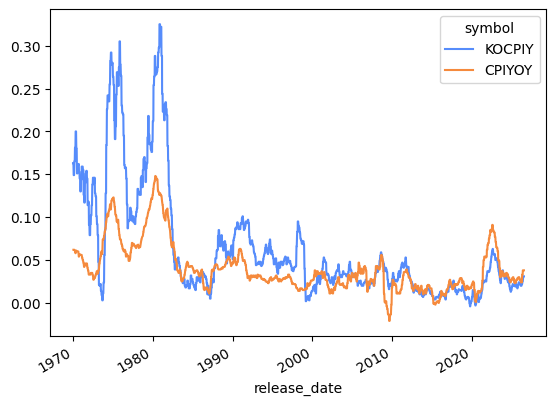

In [14]:
macro.get_series(
    symbols = ['KOCPIY','CPIYOY'],
    index_set = 'release_date',
    full_data = False
).ffill().plot()

### Behavior Service

In [17]:
from src.service.behavior import BehaviorService

behavior = BehaviorService(db_path = DB_PATH)

In [19]:
behavior.available_symbol_info()

,symbol,exchange,country
0,AAIIBEAR,AAII,United States
1,AAIIBNDFND,AAII,United States
2,AAIIBOND,AAII,United States
3,AAIIBULL,AAII,United States
4,AAIICASH,AAII,United States
5,AAIINEUT,AAII,United States
6,AAIISTCK,AAII,United States
7,AAIISTFND,AAII,United States
8,AAIITOTLBOND,AAII,United States
9,AAIITOTLSTCK,AAII,United States


In [22]:
behavior_result = behavior.get_series(
    symbols = ['NAAIMAVG','AAIIBULL'],
    full_data = False,
    index_set = 'release_date'
)

<Axes: >

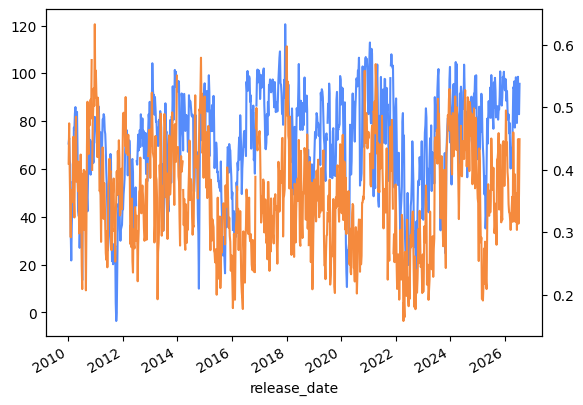

In [26]:
behavior_result.loc['2010':, 'NAAIMAVG'].plot()
behavior_result.loc['2010':, 'AAIIBULL'].plot(secondary_y = True)

### Freight Service

In [27]:
from src.service.freight import FreightService

freights = FreightService(
    db_path = DB_PATH
)

In [29]:
freights.available_symbol_info()

,symbol,exchange,country
0,BAI00,BALTIC,United Kingdom
1,BAI20,BALTIC,United Kingdom
2,BAI30,BALTIC,United Kingdom
3,BAI40,BALTIC,United Kingdom
4,BAI50,BALTIC,United Kingdom
...,...,...,...
324,WCIRDSH,DREWRY,United Kingdom
325,WCISHGN,DREWRY,United Kingdom
326,WCISHLA,DREWRY,United Kingdom
327,WCISHNY,DREWRY,United Kingdom


<Axes: xlabel='release_date'>

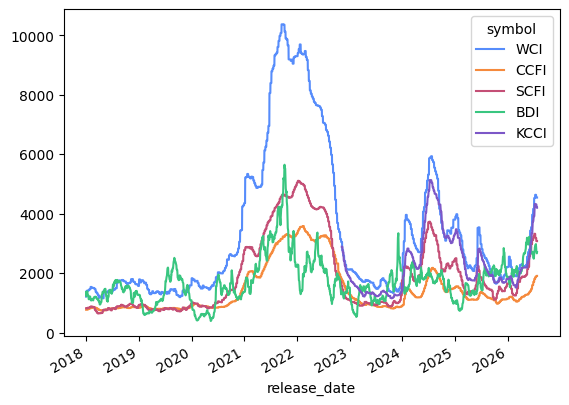

In [33]:
freights.get_series(
    symbols = [
        'WCI','CCFI','SCFI','BDI','KCCI'
    ], full_data=False,
    index_set = 'release_date',
).ffill().loc['2018':].plot()

### Fixed Income

In [34]:
from src.service.fixed_income import FixedIncomeService

fixed_income = FixedIncomeService(
    db_path = DB_PATH
)

In [35]:
fixed_income.available_symbol_info()

,symbol,exchange,country
0,CBAA-03,KOFIA,South Korea
1,CBBBB-03,KOFIA,South Korea
2,CD91,KOFIA,South Korea
3,CP91,KOFIA,South Korea
4,KDB01,KOFIA,South Korea
5,KEPCO03,KOFIA,South Korea
6,KHB05,KOFIA,South Korea
7,KOFR,KOFR,South Korea
8,KOFRIDX,KOFR,South Korea
9,KRCRS01Y,SMB,South Korea


<Axes: xlabel='release_date'>

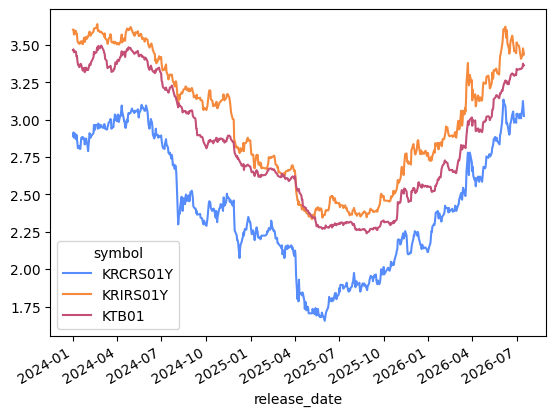

In [39]:
fixed_income.get_series(
    symbols = ['KRCRS01Y','KRIRS01Y','KTB01'],
    index_set = 'release_date',
    full_data = False
).loc['2024':].plot()